# Kuvantunnistus omilla kuvilla - CNN

## Datan ymmärrys
Datasetti sisältää yhtensä 478 kuvaa ja kuusi luokkaa. Kuvien luokat ja niiden kuvamäärät ovat seuraavat:
- Omena: 52 kuvaa
- Avokaado: 50 kuvaa
- Banaani: 104 kuvaa
- Viinirypäle: 66 kuvaa
- Kiivi: 50 kuvaa
- Appelsiini: 158 kuvaa

## Datan esikäsittely
Kuvadata on jaettu valmiiksi 70%, 15%, 15% jaolla testi- validointi- ja koulutushakemistoon. Valmiin hakemistorakenteen avulla voidaan ladata data suoraan kolmeksi Dataset-olioksi `tf.keras.preprocessing.image_dataset_from_directory`-funktiolla. Funktion parametreina annetaan hakemistojen polku, kuvien koko, eräkoko, labelien muoto ja sekoitus, jolloin data kuvat sekoitetaan.  Eräkoko määritetään jo tässä vaiheessa, jolloin datasetti palauttaa erissä 32 kuvaa ja niiden vastaavat luokat. Tämän takia eräkokoa ei tarvitse määrittää enää mallin koulutuksen yhteydessä. 

Datasetti normalisoidaan jakamalla kuvat 255:llä. Datasetti jaetaan koulutus-, validointi- ja testidatasetteihin 70%, 15% ja 15% suhteessa.

In [17]:
import keras.src.callbacks
import tensorflow as tf
import numpy as np
from numpy.f2py.crackfortran import verbose
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, \
    RandomZoom
import random

batch_size = 32
img_size = (224, 224)

# Ladataan datasetti
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../datasets/kuvantunnistus/train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../datasets/kuvantunnistus/validation",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../datasets/kuvantunnistus/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_dataset.class_names

# Normalisoidaan kuvat
train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))
validation_dataset = validation_dataset.map(lambda x, y: (x / 255.0, y))
test_dataset = test_dataset.map(lambda x, y: (x / 255.0, y))

# class names

# Tarkistetaan datasetin koko
print(f"Train batches: {len(train_dataset)}, Validation batches: {len(validation_dataset)}, Test batches: {len(test_dataset)}")

Found 216 files belonging to 6 classes.
Found 42 files belonging to 6 classes.
Found 42 files belonging to 6 classes.
Train batches: 7, Validation batches: 2, Test batches: 2


In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.2),
])

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    data_augmentation,
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    #ReduceLROnPlateau(factor=0.1, patience=3)
]

model.summary()
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=100, callbacks=callbacks, verbose=0)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,166 (91.20 MB)

 Trainable params: 23,908,166 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

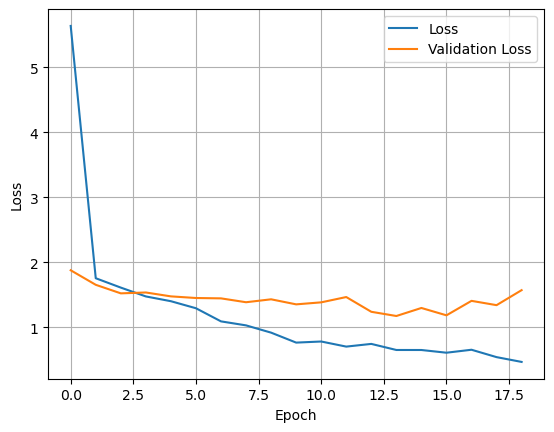

In [19]:
import matplotlib.pyplot as plt


def plot_loss(history):
    plt.plot(history.history["loss"], label="Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.legend()
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid()
    plt.show()

plot_loss(history)

In [20]:
def print_test_loss_accuracy(model):
    score = model.evaluate(test_dataset)
    print('Test loss:', score[0])
    print('Test accuracy:', score[1])

print_test_loss_accuracy(model)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5263 - loss: 1.5486
Test loss: 1.5201274156570435
Test accuracy: 0.523809552192688


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


2025-04-04 12:40:19.151567: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


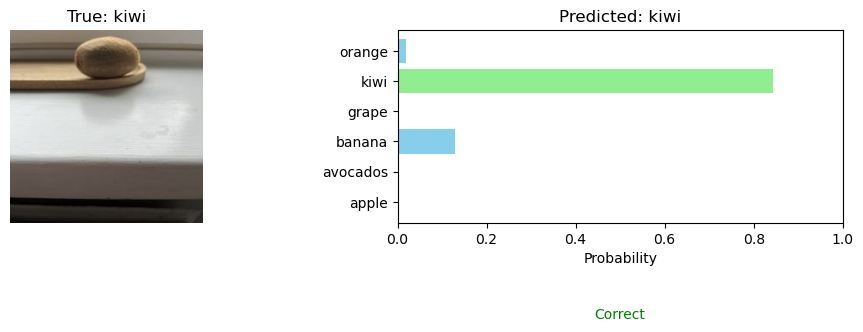

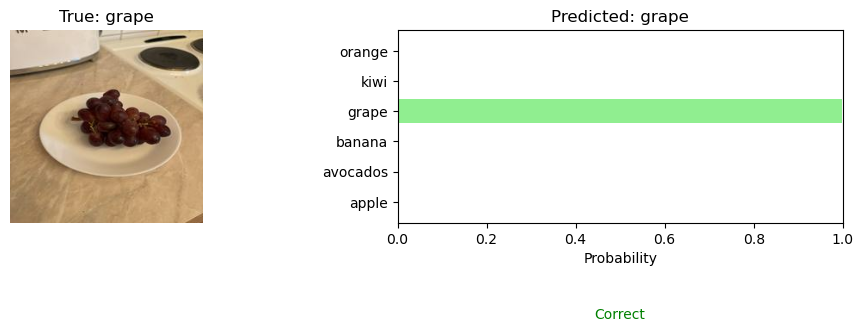

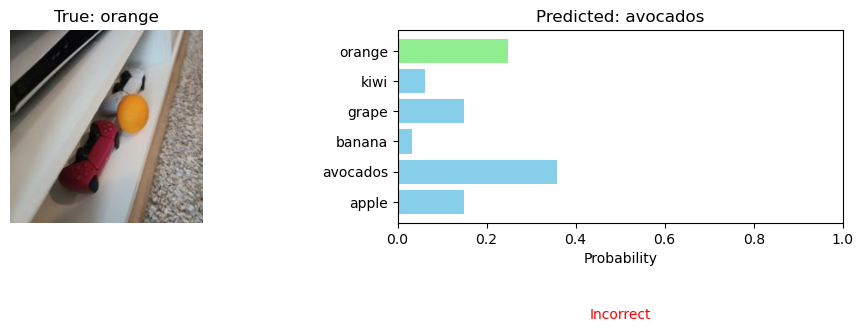

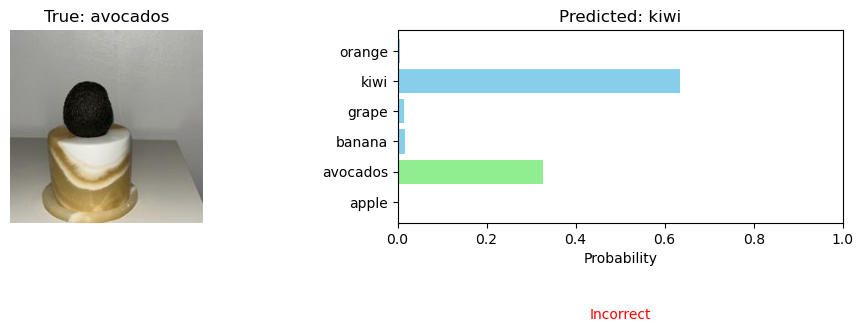

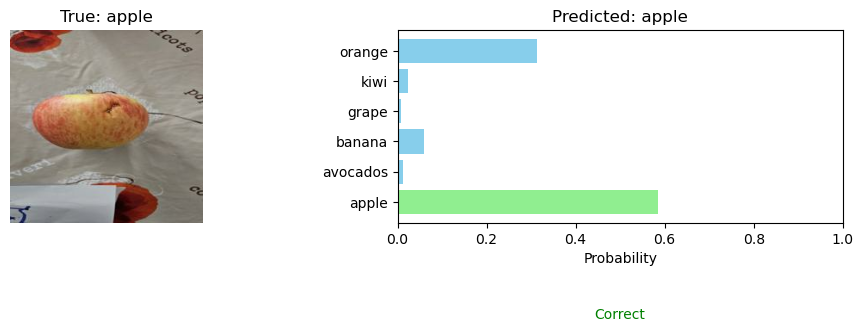

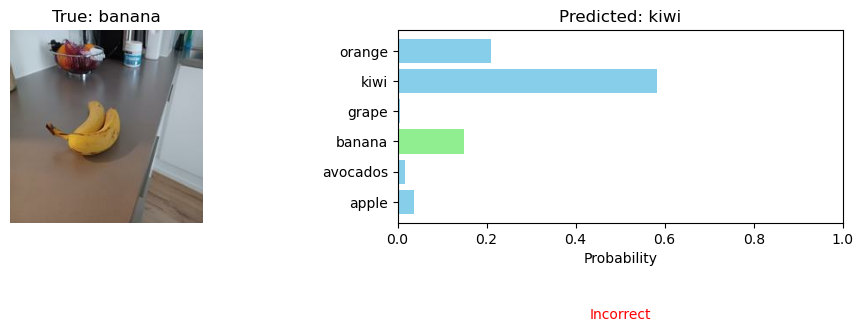

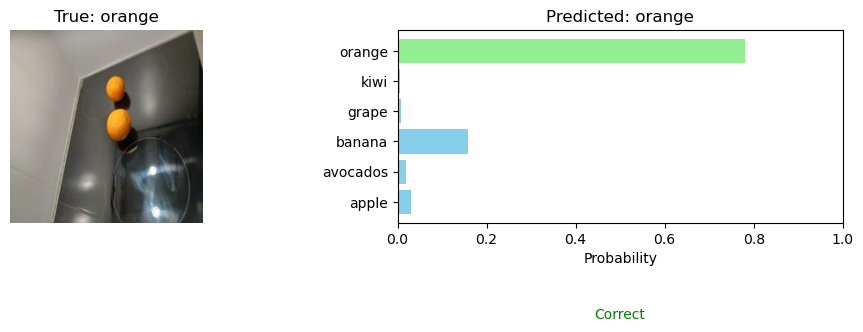

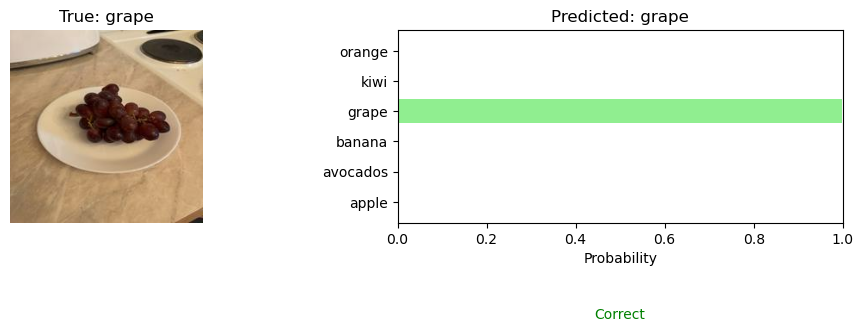

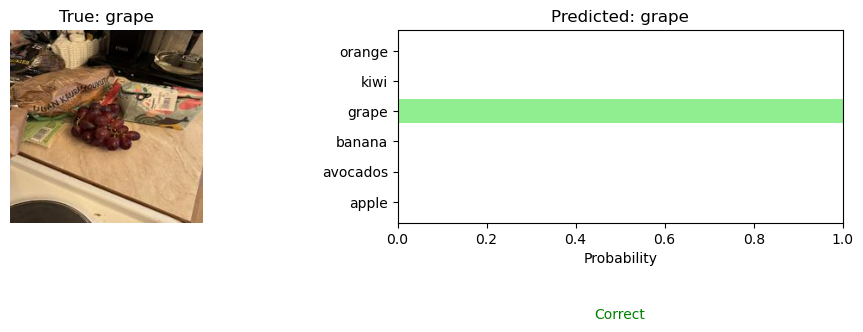

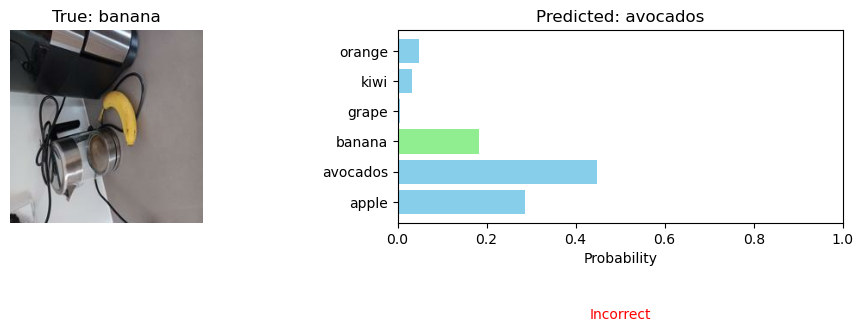

In [21]:
# Haetaan testidatasetista yksi batch
test_images, test_labels = next(iter(test_dataset.take(1)))

# Ennustetaan mallilla
predictions = model.predict(test_images)

# Muunnetaan one-hot-enkoodatut labelit kokonaisluvuiksi
true_labels = np.argmax(test_labels, axis=1)
predicted_labels = np.argmax(predictions, axis=1)


def plot_images(model):
    y_pred = []
    x_images = []
    y_true = []

    for images, labels in test_dataset:
        y_pred.extend(model.predict(images, batch_size=32))
        x_images.extend(images.numpy())
        y_true.extend(labels.numpy())

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    x_images = np.array(x_images)

    num_samples = 10
    random_indices = random.sample(range(len(x_images)), num_samples)

    for i in random_indices:
        plt.figure(figsize=(10, 4))

        # Display image
        plt.subplot(1, 2, 1)
        plt.imshow((x_images[i] * 255).astype("uint8"))
        true_class = class_names[np.argmax(y_true[i])]
        plt.title(f"True: {true_class}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        pred_prob = y_pred[i]
        predicted_class = class_names[np.argmax(pred_prob)]

        colors = ['lightgreen' if (class_names[idx] == true_class) else 'skyblue'
                  for idx in range(len(class_names))]

        plt.barh(class_names, pred_prob, color=colors)
        plt.xlabel('Probability')
        plt.title(f"Predicted: {predicted_class}")
        plt.xlim([0, 1])

        if predicted_class != true_class:
            plt.text(0.5, -0.5, "Incorrect", color='red',
                     ha='center', transform=plt.gca().transAxes)
        else:
            plt.text(0.5, -0.5, "Correct", color='green',
                     ha='center', transform=plt.gca().transAxes)

        plt.tight_layout()
        plt.show()


plot_images(model)

# Kuvantunnistus omilla kuvilla – VGG16 Assisted

Hyödynnetään VGG16-mallia, joka on esikoulutettu ImageNet-datasetillä. Viimeinen kerros poistetaan, jotta malli voidaan mukauttaa omaan datasettiin. Mallin esikoulutetut kerrokset jäädytetään, jotta niitä ei kouluteta uudelleen, ja niiden päälle lisätään oma mukautettu osuus.

In [22]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg16_base.trainable = False

## Mallin rakenteen määrittely

Omien kerrosten rakenne VGG16-mallin päälle:
- GlobalAveragePooling2D
- Dense(256, activation='relu')
- Dense(128, activation='relu', kernel_regularizer=l2(0.01))
- Dense(128, activation='relu')
- Dropout(0.2)
- Dense(6, activation='softmax')

In [23]:
x = vgg16_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(6, activation='softmax')(x)

## Mallin rakentaminen ja optimointi

Malli koostuu VGG16-pohjasta ja uusista lisäkerroksista. Optimointimenetelmänä käytetään Adam-algoritmia, kustannusfunktio on categorical_crossentropy, ja suorituskykymittarina käytetään tarkkuutta (accuracy).

In [24]:
model2 = Model(inputs=vgg16_base.input, outputs=predictions)

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(train_dataset, validation_data=validation_dataset, callbacks=callbacks, epochs=100, verbose=0)

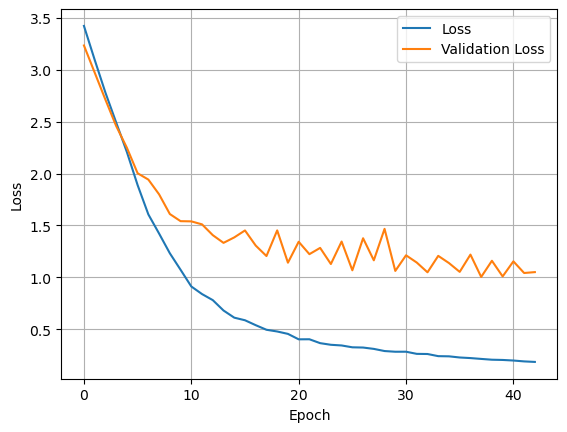

In [25]:
plot_loss(history2)

## Mallin suorituskyvyn arviointi

Esikoulutetun VGG16-mallin tarkkuus on noin 80 %, ja kustannusarvo on noin 0.66.

In [26]:
print_test_loss_accuracy(model2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8209 - loss: 0.6426
Test loss: 0.6654278635978699
Test accuracy: 0.8095238208770752


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step


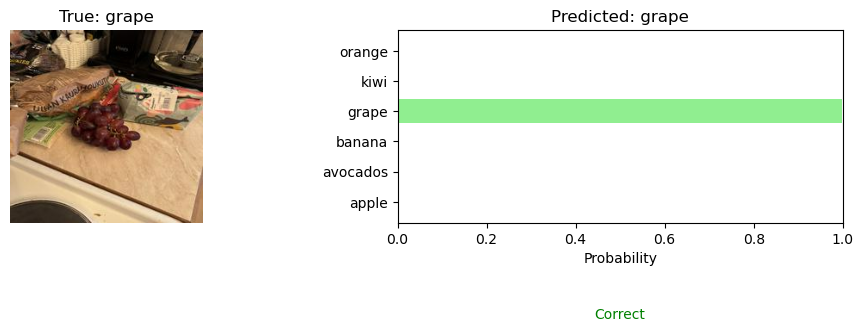

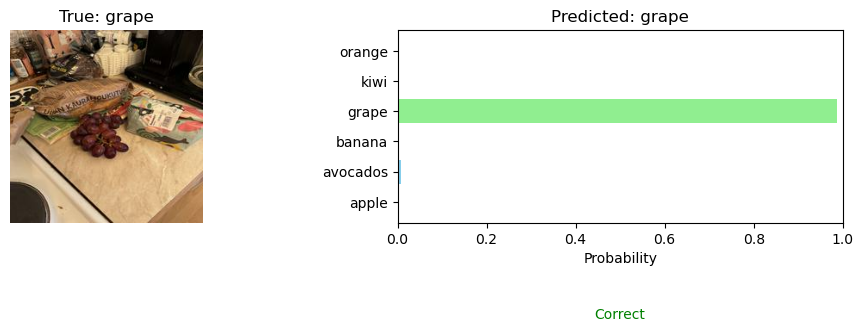

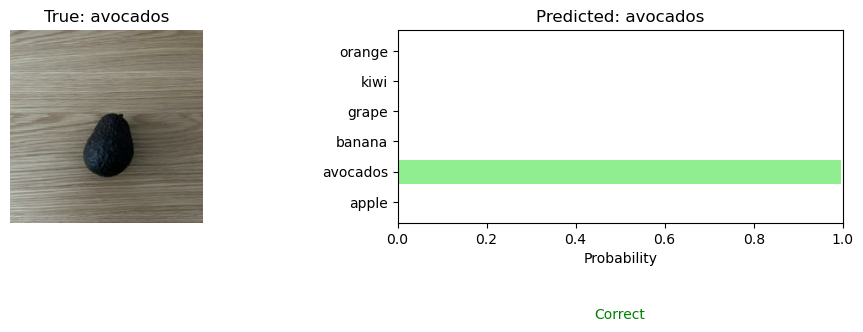

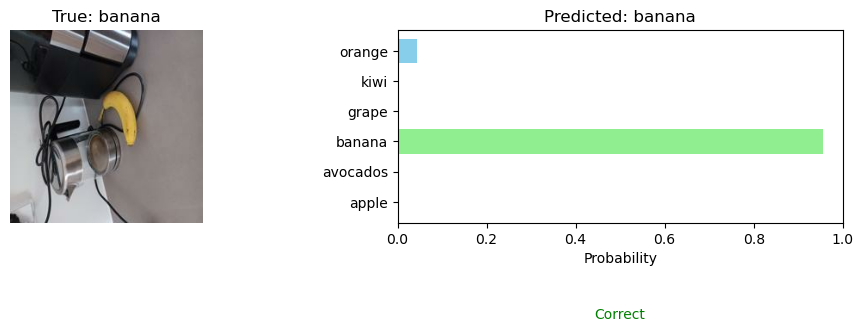

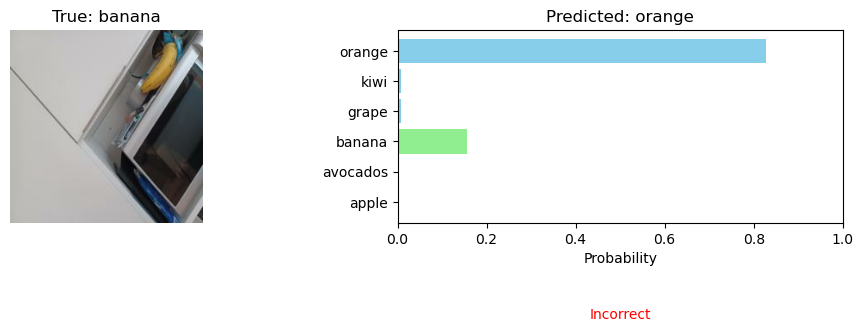

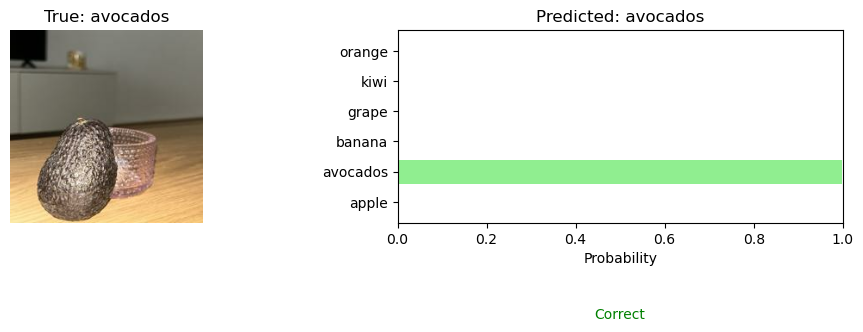

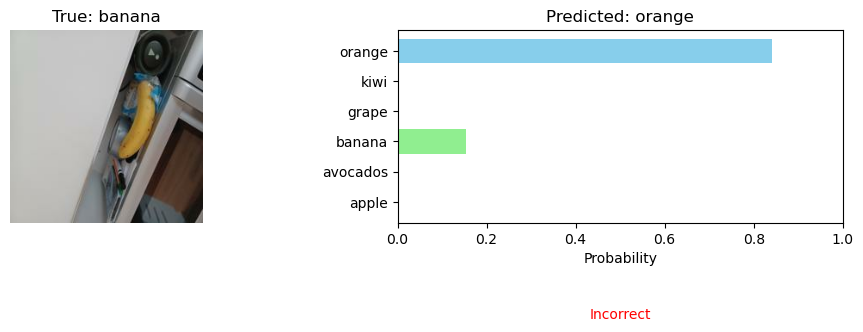

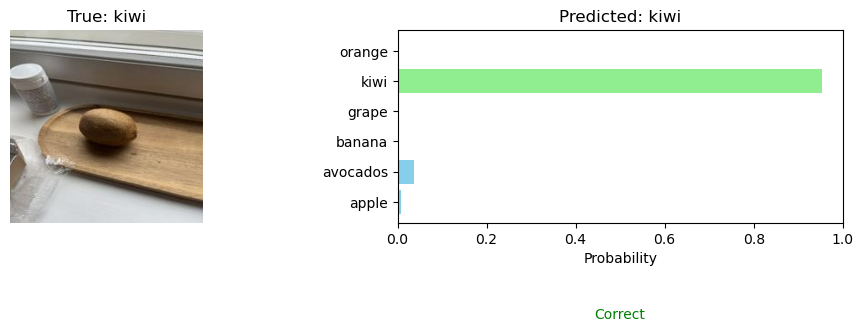

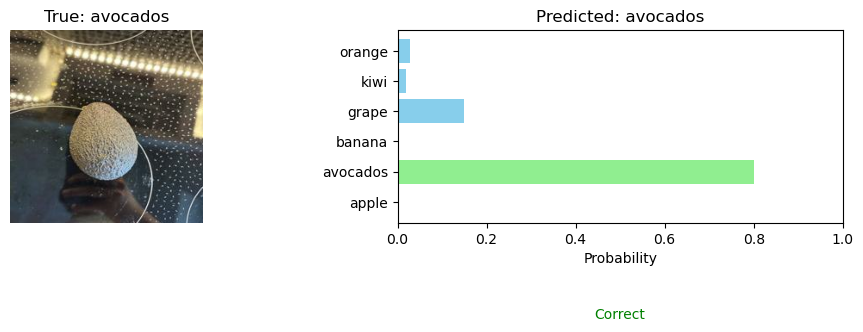

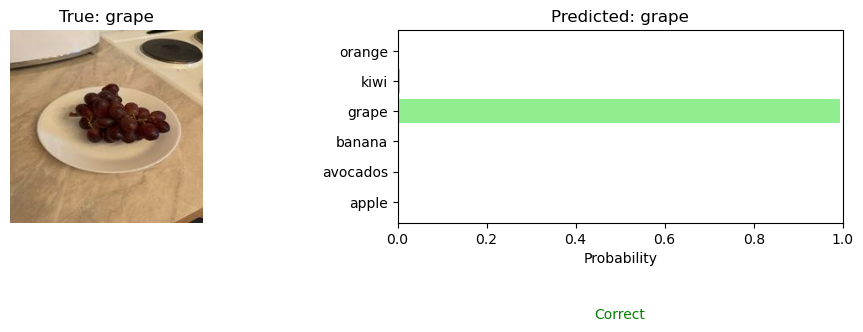

In [27]:
plot_images(model2)

# Esikoulutetun ja oman mallin vertailu
Mallit koulutettiin 100 epookilla ja eräkoolla 32. Ylioppimisen vähentämiseksi käytettiin EarlyStopping-callbackia, jonka kärsivällisyysarvo on 5. Tämä tarkoittaa, että koulutus keskeytyy, jos validointihäviö ei parane viiden epookin aikana, ja samalla palautetaan parhaat painotukset. Lisäksi ReduceLROnPlateau-callback pienentää oppimisnopeutta, jos validointihäviö ei parane kolmen epookin aikana.

Oma CNN-malli saavutti oppimisen noin 20 epookin kohdalla, kun taas esikoulutettu VGG16-malli tarvitsi noin 40 epookkia. Esikoulutetun mallin tarkkuus on 80 %, mikä on hieman parempi kuin oman mallin noin 50% tarkkuus. Suurempi ero näkyy kuitenkin kustannusfunktiossa: VGG16:n kustannusarvo on 0.66, kun taas oman mallin kustannusarvo on 1.5, mikä osoittaa esikoulutetun mallin selvästi paremman suorituskyvyn.

# Hienosäädetty esikoulutettu malli VGG16

In [28]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load VGG16 base model
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze initial layers and unfreeze later ones for fine-tuning
for layer in vgg16_base.layers[:15]:  # Freeze first 15 layers
    layer.trainable = False
for layer in vgg16_base.layers[15:]:  # Unfreeze last few layers
    layer.trainable = True

# Add custom layers
x = vgg16_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

# Create model
model3 = Model(inputs=vgg16_base.input, outputs=predictions)

model3.summary()

optimizer = Adam(learning_rate=0.00001)  # Lower learning rate for fine-tuning

model3.compile(optimizer=optimizer,
               loss='categorical_crossentropy',
               metrics=['accuracy'])

history3 = model3.fit(train_dataset,
                      validation_data=validation_dataset,
                      epochs=100,  # More epochs for fine-tuning
                      callbacks=callbacks)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 7,212,294 (27.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 462ms/step - accuracy: 0.1102 - loss: 2.0784 - val_accuracy: 0.1429 - val_loss: 1.8572
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.2544 - loss: 1.8695 - val_accuracy: 0.2381 - val_loss: 1.7902
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.2342 - loss: 1.7885 - val_accuracy: 0.2381 - val_loss: 1.7392
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2945 - loss: 1.7069 - val_accuracy: 0.3810 - val_loss: 1.6859
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3085 - loss: 1.7176 - val_accuracy: 0.3333 - val_loss: 1.6406
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3548 - loss: 1.6325 - val_accuracy: 0.4048 - val_loss: 1.5991
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3876 - loss: 1.5439 - val_accuracy: 0.3571 - val_loss: 1.5552
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4320 - loss: 1.4297 - val_accuracy: 0.3571 - val_loss

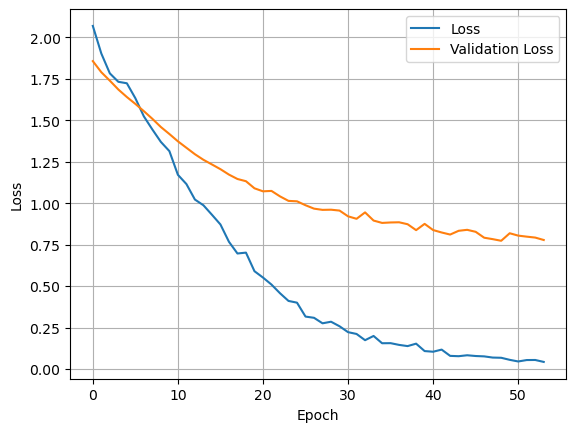

In [29]:
plot_loss(history3)

In [30]:
print_test_loss_accuracy(model3)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8472 - loss: 0.3899
Test loss: 0.4268559515476227
Test accuracy: 0.8333333134651184


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step


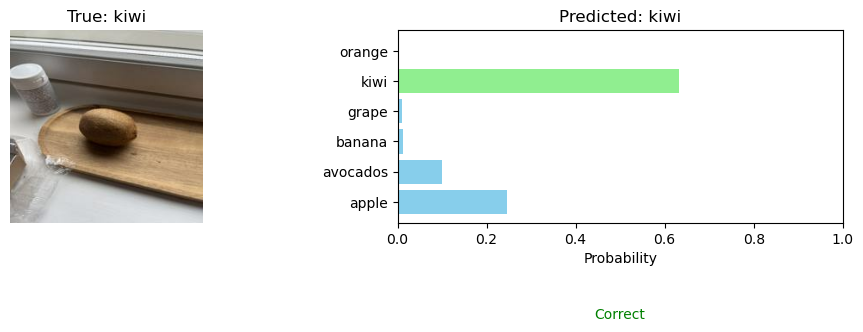

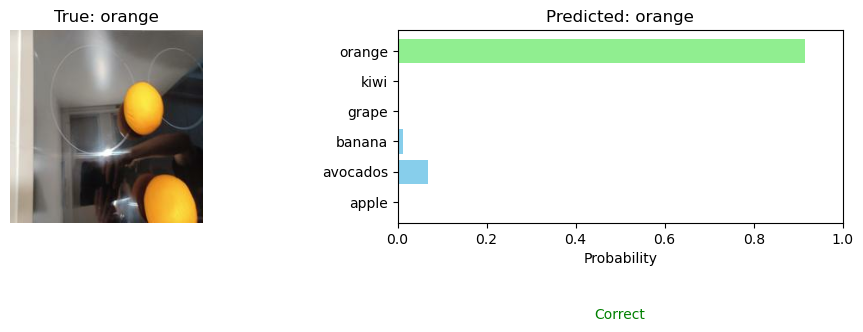

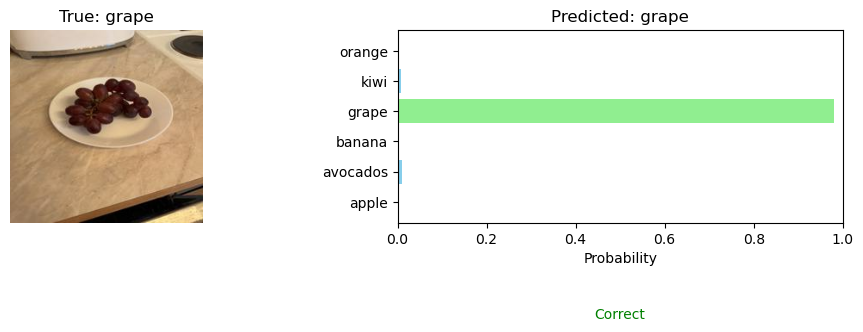

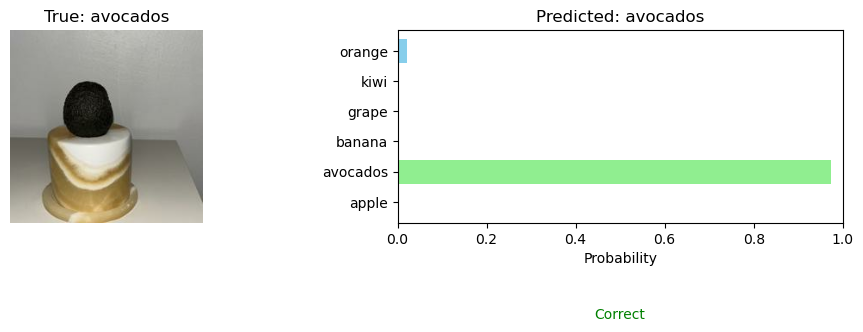

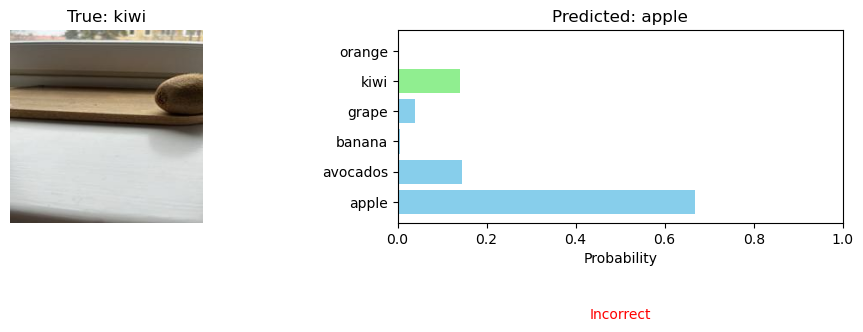

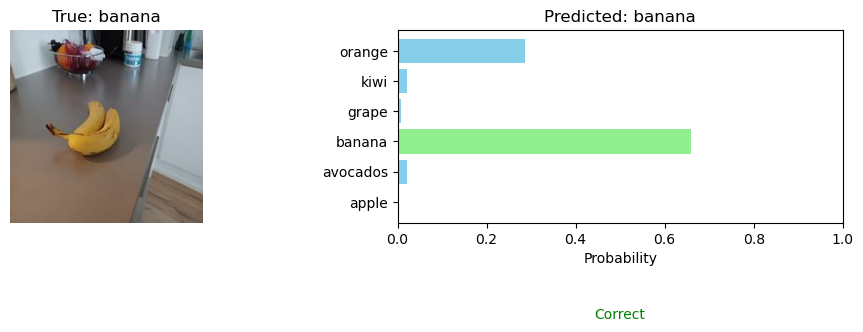

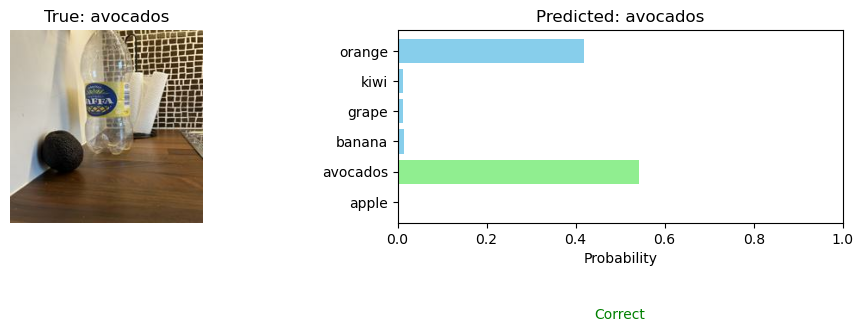

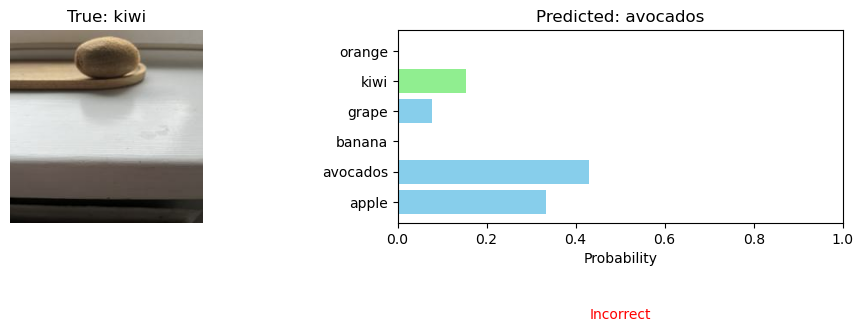

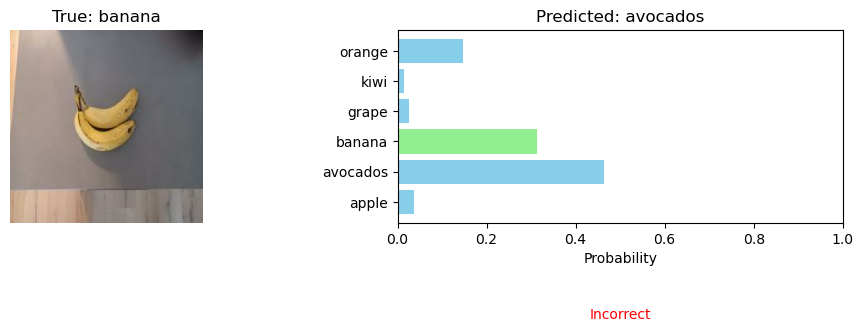

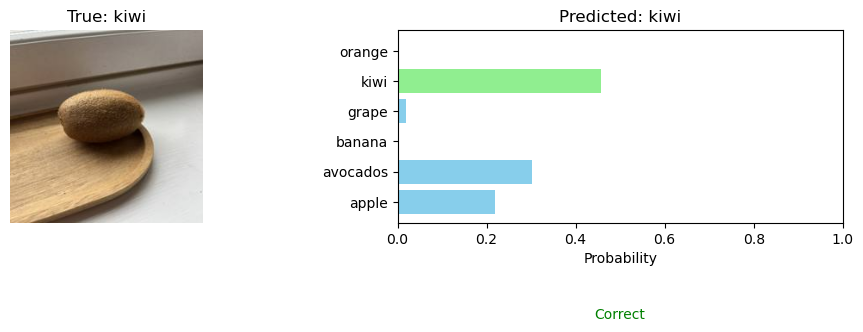

In [31]:
plot_images(model3)